In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Better plot appearance
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display settings
pd.set_option("display.max_columns", None)

In [2]:
merged = pd.read_csv(
    "../data/processed/merged_data.csv",
    parse_dates=["TransactionDate"]
)

merged.head()

,TransactionID,UserID,CourseID,TransactionDate,UserName,Age,AgeGroup,Gender,CourseName,CourseCategory,CourseType,CourseLevel,Year,Month,MonthName,Quarter,DayOfWeek
0,TT00001,U00003,CR00016,2025-10-25,morrisonamanda,33,26-35,Female,Digital Marketing,Marketing,Free,Intermediate,2025,10,October,4,Saturday
1,TT00002,U00003,CR00037,2025-01-13,morrisonamanda,33,26-35,Female,Scrum Essentials,Project Management,Free,Intermediate,2025,1,January,1,Monday
2,TT00003,U00003,CR00019,2025-03-28,morrisonamanda,33,26-35,Female,Content Marketing,Marketing,Free,Advanced,2025,3,March,1,Friday
3,TT00004,U00004,CR00048,2025-06-02,fthornton,23,18-25,Female,AI Ethics,Artificial Intelligence,Free,Beginner,2025,6,June,2,Monday
4,TT00005,U00004,CR00060,2025-08-10,fthornton,23,18-25,Female,Content Creation,Digital Marketing,Free,Beginner,2025,8,August,3,Sunday


In [3]:
total_users = merged["UserID"].nunique()
total_courses = merged["CourseID"].nunique()
total_enrollments = len(merged)

avg_age = merged["Age"].mean()

avg_courses_per_user = (
    merged.groupby("UserID")
          .size()
          .mean()
)

print(f"Total Users: {total_users}")
print(f"Total Courses: {total_courses}")
print(f"Total Enrollments: {total_enrollments}")
print(f"Average Age: {avg_age:.2f}")
print(f"Average Courses per Learner: {avg_courses_per_user:.2f}")

Total Users: 3000
Total Courses: 60
Total Enrollments: 10000
Average Age: 24.97
Average Courses per Learner: 3.33


1. Age Distribution

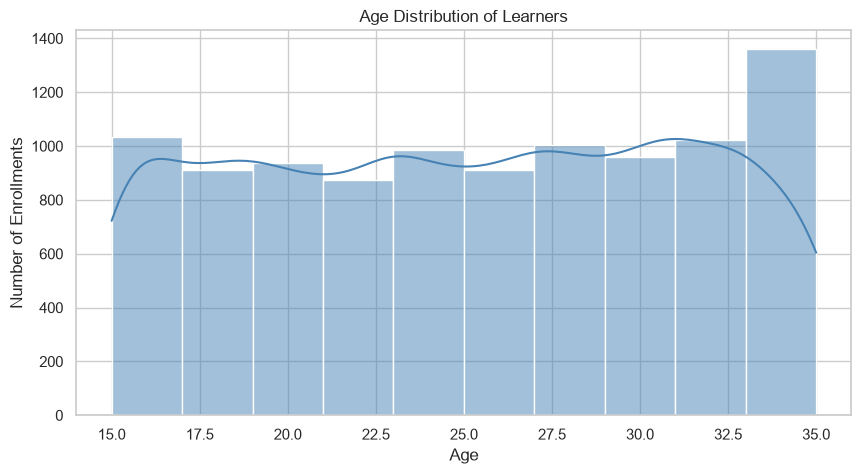

In [4]:
plt.figure(figsize=(10,5))

sns.histplot(
    merged["Age"],
    bins=10,
    kde=True,
    color="steelblue"
)

plt.title("Age Distribution of Learners")
plt.xlabel("Age")
plt.ylabel("Number of Enrollments")

plt.show()

2. Age Group Distribution

C:\Users\sachi\AppData\Local\Temp\ipykernel_27876\2694294265.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


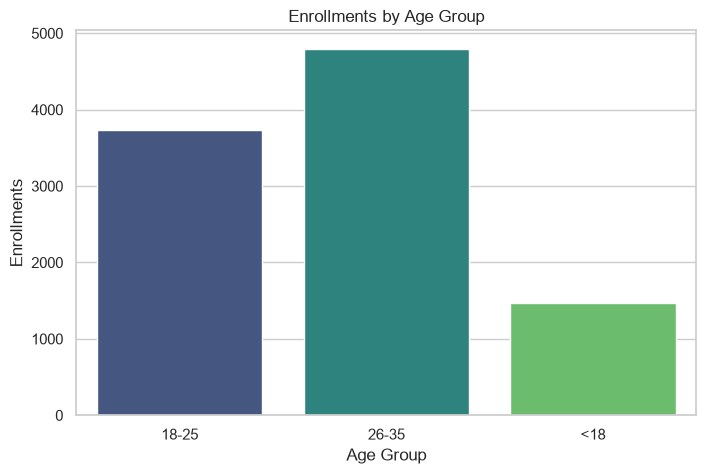

In [5]:
age_counts = (
    merged["AgeGroup"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=age_counts.index,
    y=age_counts.values,
    palette="viridis"
)

plt.title("Enrollments by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Enrollments")

plt.show()

3. Gender Distribution

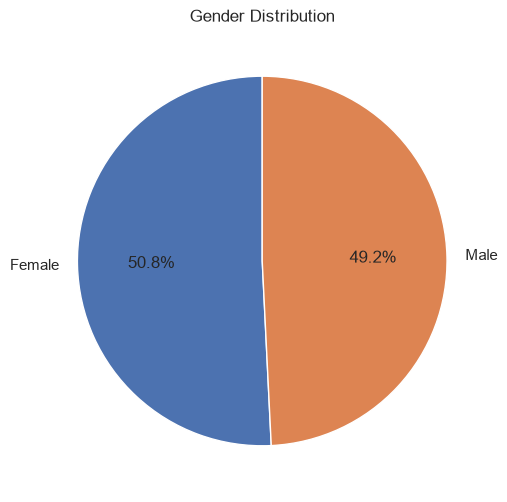

In [6]:
gender = merged["Gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender.values,
    labels=gender.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.show()

4. Course Category Popularity

C:\Users\sachi\AppData\Local\Temp\ipykernel_27876\3901864542.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


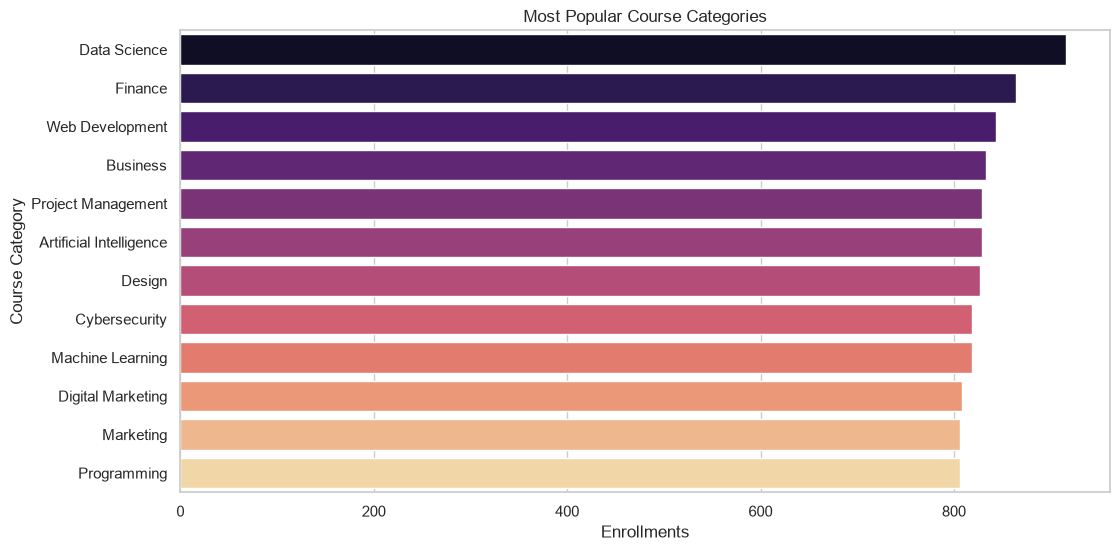

In [7]:
category = (
    merged["CourseCategory"]
    .value_counts()
)

plt.figure(figsize=(12,6))

sns.barplot(
    y=category.index,
    x=category.values,
    palette="magma"
)

plt.title("Most Popular Course Categories")
plt.xlabel("Enrollments")
plt.ylabel("Course Category")

plt.show()

Course Level Distribution

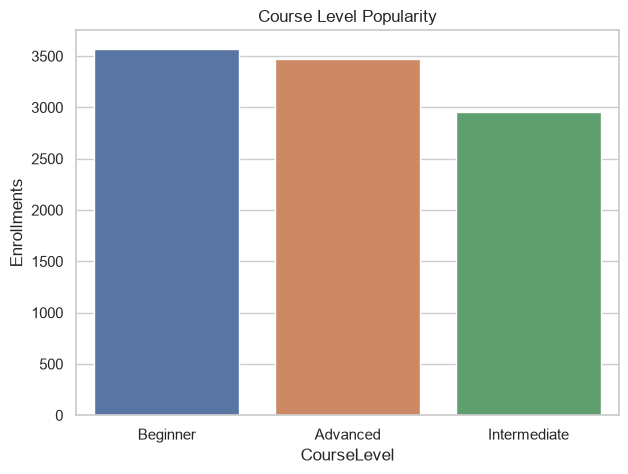

In [10]:
level = merged["CourseLevel"].value_counts()

plt.figure(figsize=(7,5))

sns.barplot(
    x=level.index,
    y=level.values,
    hue=level.index,
    legend=False,
)

plt.title("Course Level Popularity")
plt.ylabel("Enrollments")

plt.show()

Course Type Distribution

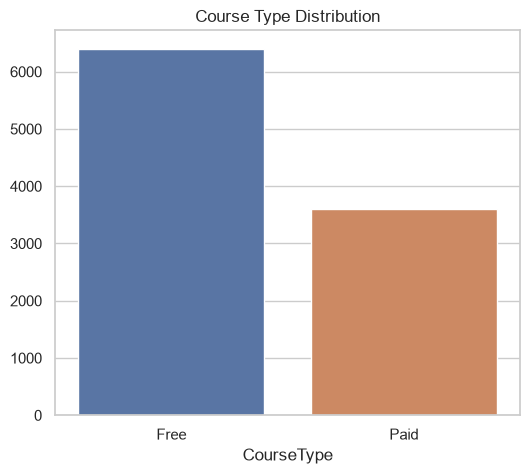

In [12]:
course_type = merged["CourseType"].value_counts()

plt.figure(figsize=(6,5))

sns.barplot(
    x=course_type.index,
    y=course_type.values,
    hue=course_type.index,
    legend=False
    
)

plt.title("Course Type Distribution")

plt.show()

Top 10 Most Enrolled Courses

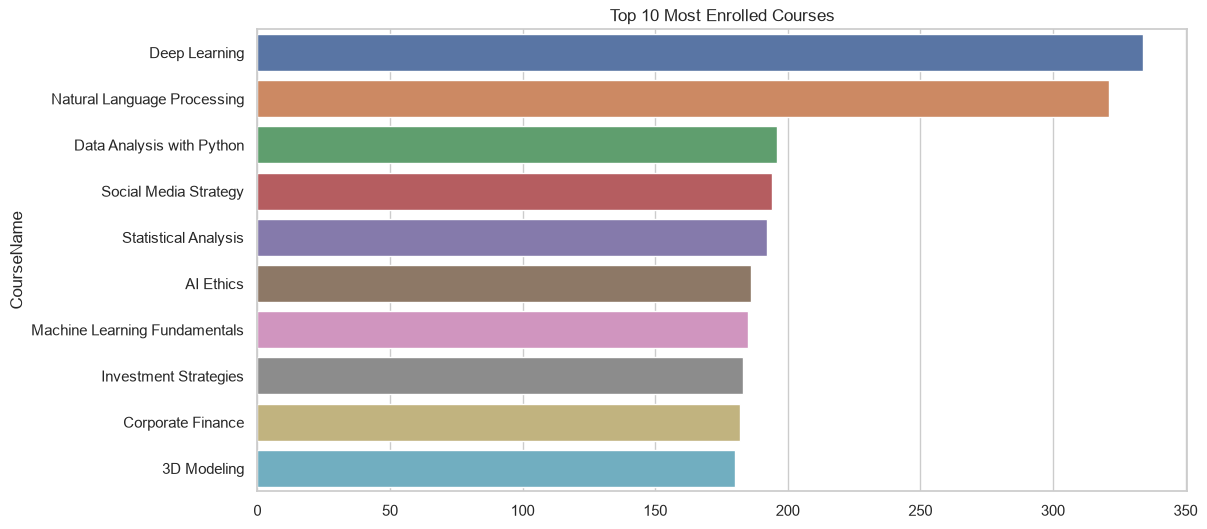

In [16]:
top_courses = (
    merged["CourseName"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    y=top_courses.index,
    x=top_courses.values,
    hue= top_courses.index,
    legend=False
)

plt.title("Top 10 Most Enrolled Courses")

plt.show()

8. Average Courses per Learner

In [17]:
courses_per_user = (
    merged.groupby("UserID")
          .size()
)

courses_per_user.describe()

count    3000.000000
mean        3.333333
std         4.352149
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max        16.000000
dtype: float64

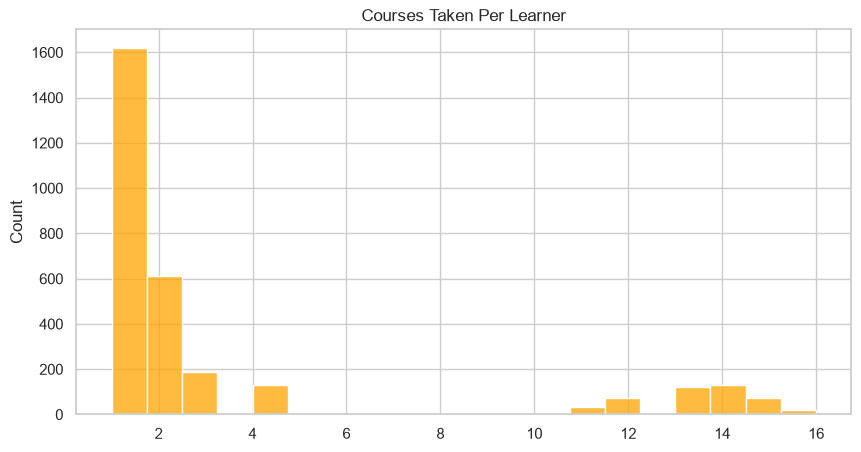

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(
    courses_per_user,
    bins=20,
    color="orange"
)

plt.title("Courses Taken Per Learner")

plt.show()

Top Active Learners

In [19]:
top_users = (
    merged.groupby("UserName")
          .size()
          .sort_values(ascending=False)
          .head(10)
)

top_users

UserName
hthomas            16
taylorelizabeth    16
jayala             16
smithjames         16
tanya67            16
jared15            16
david25            16
blake28            16
bernardsexton      16
gordonjulie        16
dtype: int64

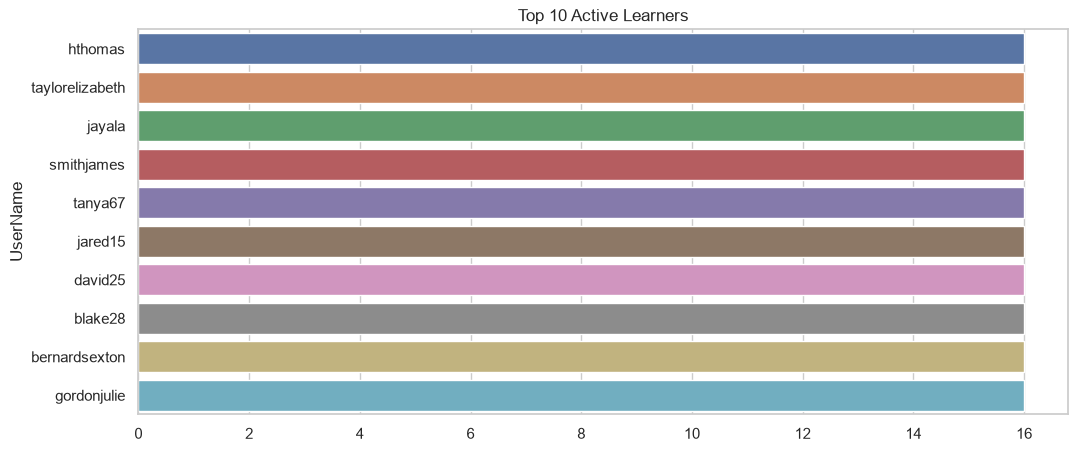

In [21]:
plt.figure(figsize=(12,5))

sns.barplot(
    y=top_users.index,
    x=top_users.values,
    hue=top_users.index,
    legend=False
)

plt.title("Top 10 Active Learners")

plt.show()

10. Age Group vs Course Category

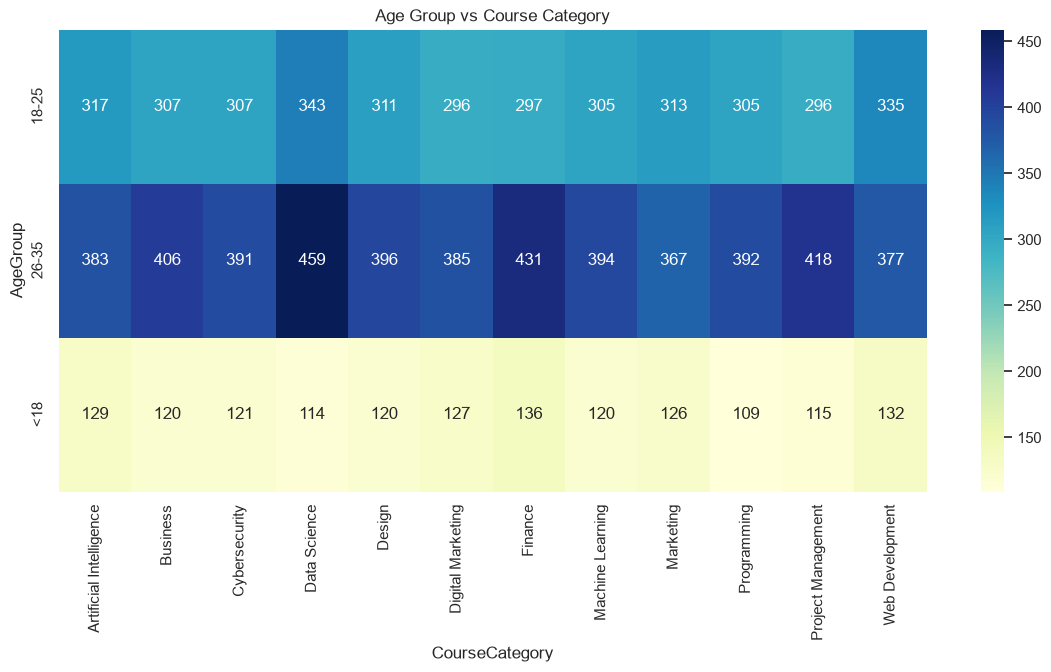

In [23]:
pivot = pd.crosstab(
    merged["AgeGroup"],
    merged["CourseCategory"]
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="YlGnBu",
    fmt="d"
)

plt.title("Age Group vs Course Category")

plt.show()

11. Gender vs Course Level

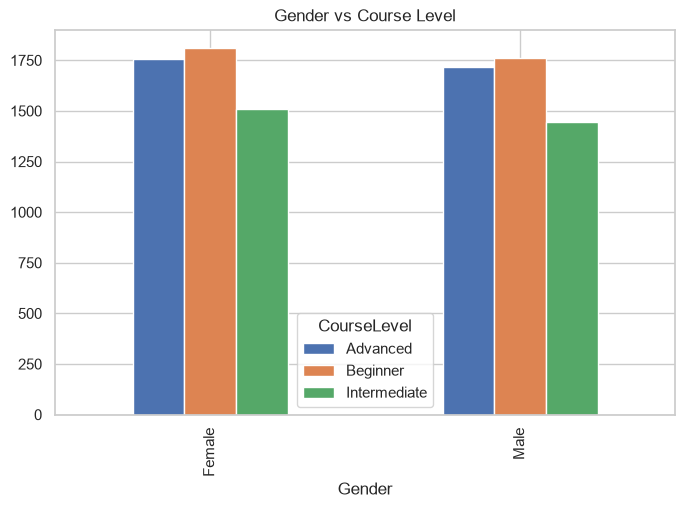

In [24]:
pivot = pd.crosstab(
    merged["Gender"],
    merged["CourseLevel"]
)

pivot.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Gender vs Course Level")

plt.show()

12. Monthly Enrollment Trend

In [25]:
month = (
    merged.groupby("MonthName")
          .size()
)

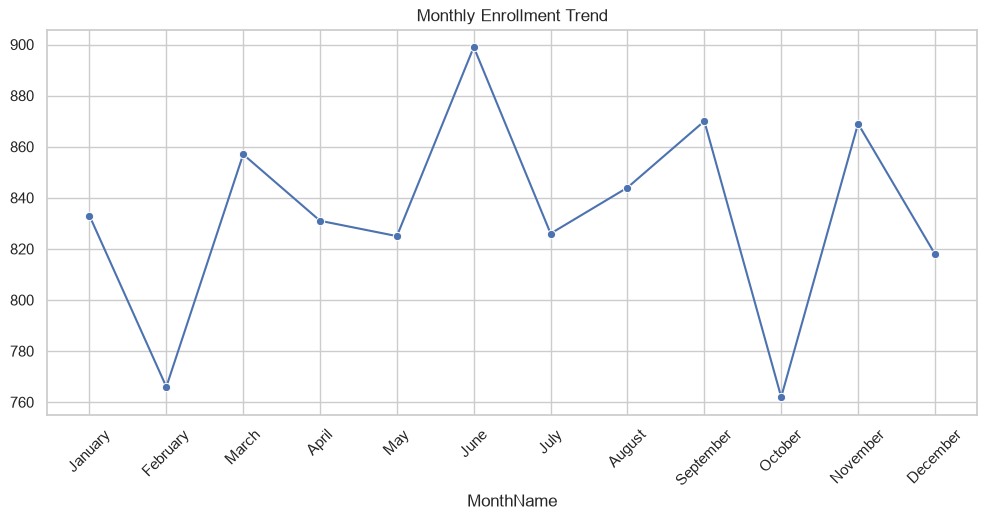

In [26]:
months = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

month = (
    merged.groupby("MonthName")
          .size()
          .reindex(months)
)

plt.figure(figsize=(12,5))

sns.lineplot(
    x=month.index,
    y=month.values,
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Enrollment Trend")

plt.show()

In [27]:
summary = pd.DataFrame({
    "Metric": [
        "Total Users",
        "Total Courses",
        "Total Enrollments",
        "Average Age",
        "Average Courses per Learner"
    ],
    "Value": [
        total_users,
        total_courses,
        total_enrollments,
        round(avg_age,2),
        round(avg_courses_per_user,2)
    ]
})

summary

,Metric,Value
0,Total Users,3000.00
1,Total Courses,60.00
2,Total Enrollments,10000.00
3,Average Age,24.97
4,Average Courses per Learner,3.33


In [28]:
age_group_percent = (
    merged["AgeGroup"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(age_group_percent)

AgeGroup
26-35    47.99
18-25    37.32
<18      14.69
Name: proportion, dtype: float64


In [29]:
def print_heading(title):
    print("\n" + "="*60)
    print(title)
    print("="*60)

In [30]:
print_heading("Platform KPIs")

total_users = merged["UserID"].nunique()
total_courses = merged["CourseID"].nunique()
total_enrollments = len(merged)

avg_age = merged["Age"].mean()

avg_courses = (
    merged.groupby("UserID")
          .size()
          .mean()
)

print(f"Total Users              : {total_users}")
print(f"Total Courses            : {total_courses}")
print(f"Total Enrollments        : {total_enrollments}")
print(f"Average Age              : {avg_age:.2f} years")
print(f"Average Courses/Learner  : {avg_courses:.2f}")


Platform KPIs
Total Users              : 3000
Total Courses            : 60
Total Enrollments        : 10000
Average Age              : 24.97 years
Average Courses/Learner  : 3.33


In [31]:
age_group = (
    merged["AgeGroup"]
    .value_counts()
    .sort_index()
)

age_percent = (
    merged["AgeGroup"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(pd.DataFrame({
    "Enrollments": age_group,
    "Percentage": age_percent
}))

,Enrollments,Percentage
AgeGroup,,
18-25,3732,37.32
26-35,4799,47.99
<18,1469,14.69


In [32]:
largest = age_percent.idxmax()
largest_pct = age_percent.max()

print()

print(
    f"The largest learner segment is '{largest}' "
    f"with {largest_pct:.2f}% of total enrollments."
)


The largest learner segment is '26-35' with 47.99% of total enrollments.


In [33]:
ctype = merged["CourseType"].value_counts()

display(ctype)

print()

print(
    f"The majority of enrollments are in "
    f"{ctype.idxmax()} courses."
)

CourseType
Free    6403
Paid    3597
Name: count, dtype: int64


The majority of enrollments are in Free courses.


In [34]:
print_heading("Key Findings")

print(f"✓ Total learners analysed        : {total_users}")
print(f"✓ Total enrollments              : {total_enrollments}")
print(f"✓ Most active age group          : {age_percent.idxmax()}")
print(f"✓ Highest enrolled category      : {category.idxmax()}")
print(f"✓ Preferred course level         : {level.idxmax()}")
print(f"✓ Preferred course type          : {ctype.idxmax()}")
print(f"✓ Most enrolled course           : {top_courses.index[0]}")
print(f"✓ Average courses per learner    : {avg_courses:.2f}")


Key Findings
✓ Total learners analysed        : 3000
✓ Total enrollments              : 10000
✓ Most active age group          : 26-35
✓ Highest enrolled category      : Data Science
✓ Preferred course level         : Beginner
✓ Preferred course type          : Free
✓ Most enrolled course           : Deep Learning
✓ Average courses per learner    : 3.33
